In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Yield_pred/merged_potato_reservoir.csv')

# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# Optional: Summary statistics for numerical columns to check for data consistency
print("\nSummary statistics of the dataset:\n", df.describe())


Missing values per column:
 state_name                     0
crop_name                      0
apy_item_interval_start        0
temperature_recorded_date      0
state_temperature_max_val      0
state_temperature_min_val      0
state_rainfall_val             0
yield                          0
FRL                            0
Live Cap FRL                   0
Level                        382
Current Live Storage         382
dtype: int64
Number of duplicate rows: 0

Summary statistics of the dataset:
        apy_item_interval_start  state_temperature_max_val  \
count             47848.000000               47848.000000   
mean               2014.045645                  33.566005   
std                   5.432290                   5.031233   
min                2000.000000                  11.110000   
25%                2010.000000                  31.070000   
50%                2015.000000                  33.420000   
75%                2019.000000                  36.560000   
max       

In [ ]:
rows_with_missing = df[df.isnull().any(axis=1)]
rows_with_missing.head()

,state_name,crop_name,apy_item_interval_start,temperature_recorded_date,state_temperature_max_val,state_temperature_min_val,state_rainfall_val,yield,FRL,Live Cap FRL,Level,Current Live Storage
2511,Andhra Pradesh,potato,2018,2018-11-16,33.36,18.35,2.73,6.21237,152.296667,2.838333,NaN,NaN
2512,Andhra Pradesh,potato,2018,2018-11-17,33.17,19.03,7.54,6.21237,152.296667,2.838333,NaN,NaN
2513,Andhra Pradesh,potato,2018,2018-11-18,33.87,19.81,1.82,6.21237,152.296667,2.838333,NaN,NaN
2515,Andhra Pradesh,potato,2018,2018-11-20,33.29,19.46,0.00,6.21237,152.296667,2.838333,NaN,NaN
2517,Andhra Pradesh,potato,2018,2018-11-22,31.23,18.05,7.86,6.21237,152.296667,2.838333,NaN,NaN


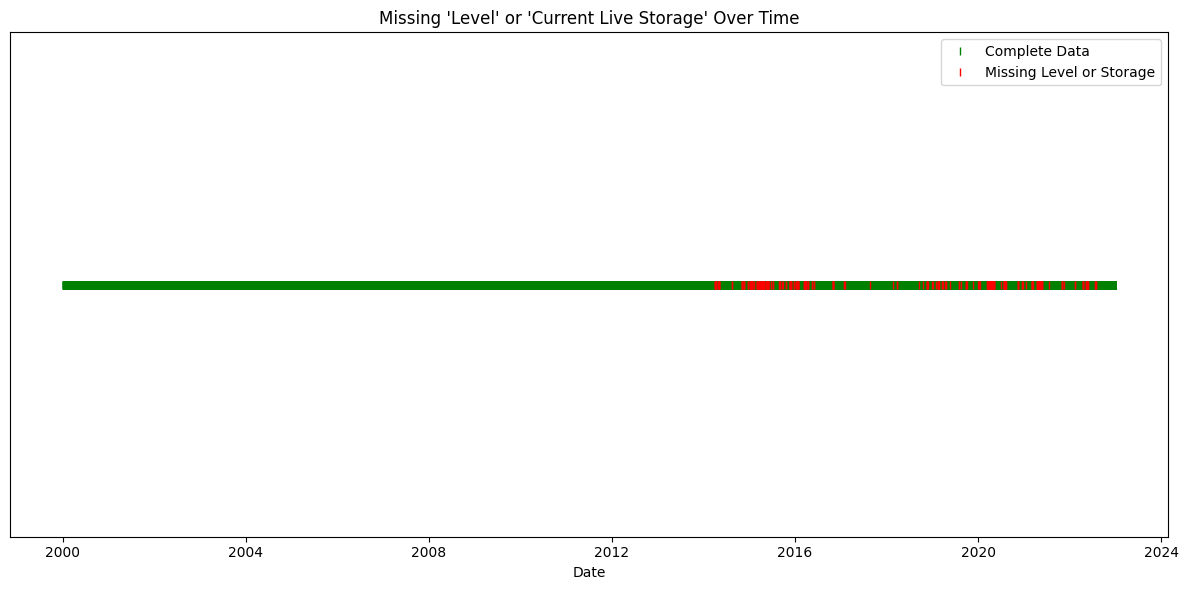

In [ ]:
import matplotlib.pyplot as plt

# Convert date column to datetime format
df['temperature_recorded_date'] = pd.to_datetime(df['temperature_recorded_date'])

# Create a mask for missing values in 'Level' or 'Current Live Storage'
missing_mask = df['Level'].isna() | df['Current Live Storage'].isna()

# Plot missing data points over time
plt.figure(figsize=(12, 6))
plt.plot(df.loc[~missing_mask, 'temperature_recorded_date'], [1]*sum(~missing_mask),
         '|', color='green', label='Complete Data')
plt.plot(df.loc[missing_mask, 'temperature_recorded_date'], [1]*sum(missing_mask),
         '|', color='red', label='Missing Level or Storage')

plt.yticks([])
plt.xlabel("Date")
plt.title("Missing 'Level' or 'Current Live Storage' Over Time")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Ensure the date column is sorted and set as the index for time-based interpolation
df = df.sort_values('temperature_recorded_date')
df = df.set_index(pd.to_datetime(df['temperature_recorded_date']))

# Apply time-based interpolation for the columns with missing values
df['Level'] = df['Level'].interpolate(method='time')
df['Current Live Storage'] = df['Current Live Storage'].interpolate(method='time')

# Reset index back to default
df = df.reset_index(drop=True)

# Check again for missing values to confirm interpolation worked
missing_after_interpolation = df[['Level', 'Current Live Storage']].isnull().sum()
missing_after_interpolation

,0
Level,0
Current Live Storage,0


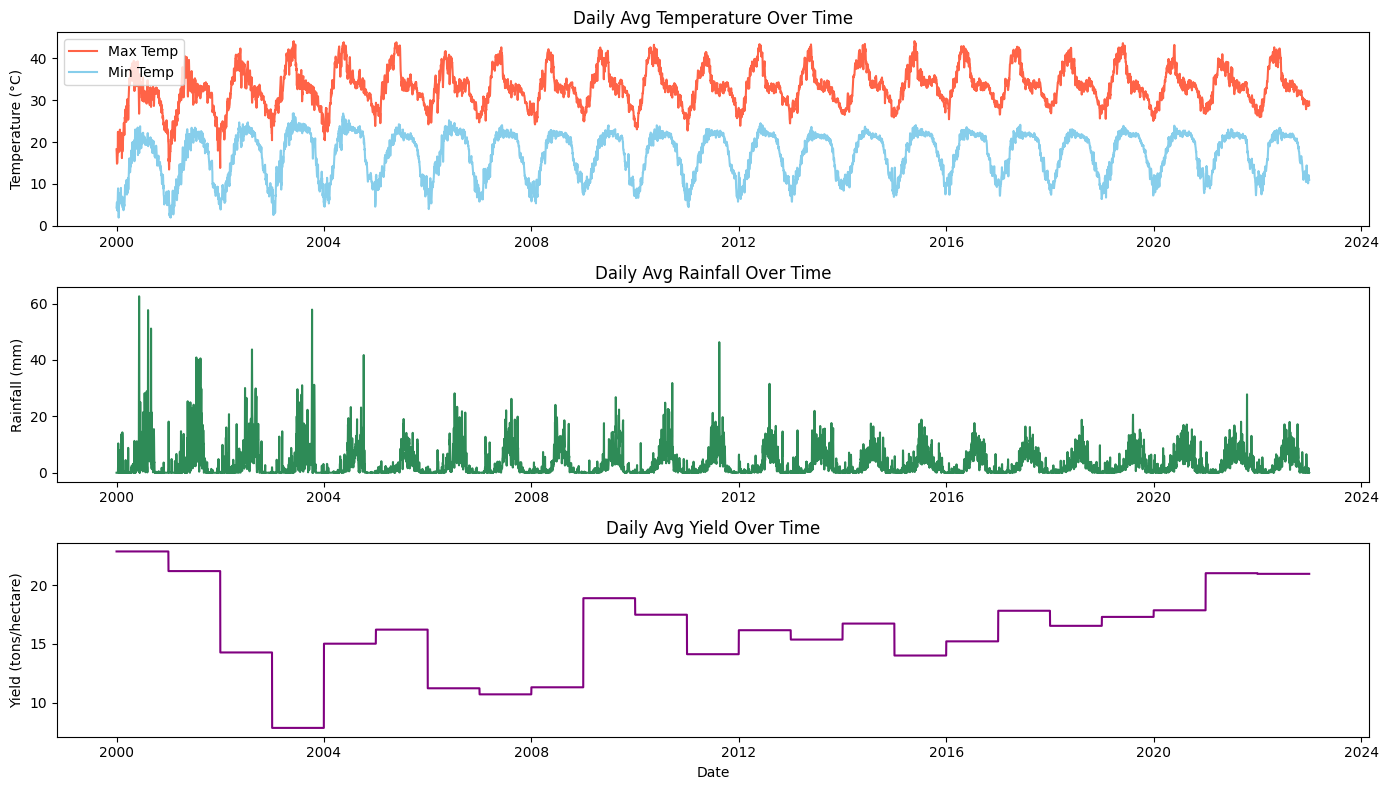

In [ ]:
df['temperature_recorded_date'] = pd.to_datetime(df['temperature_recorded_date'])

# Group by date and compute daily average for temperature, rainfall, and yield
daily_avg = df.groupby('temperature_recorded_date')[[
    'state_temperature_max_val',
    'state_temperature_min_val',
    'state_rainfall_val',
    'yield']].mean()

# Plotting
plt.figure(figsize=(14, 8))

# Max Temperature
plt.subplot(3, 1, 1)
plt.plot(daily_avg.index, daily_avg['state_temperature_max_val'], color='tomato', label='Max Temp')
plt.plot(daily_avg.index, daily_avg['state_temperature_min_val'], color='skyblue', label='Min Temp')
plt.ylabel("Temperature (°C)")
plt.title("Daily Avg Temperature Over Time")
plt.legend()

# Rainfall
plt.subplot(3, 1, 2)
plt.plot(daily_avg.index, daily_avg['state_rainfall_val'], color='seagreen')
plt.ylabel("Rainfall (mm)")
plt.title("Daily Avg Rainfall Over Time")

# Yield
plt.subplot(3, 1, 3)
plt.plot(daily_avg.index, daily_avg['yield'], color='purple')
plt.ylabel("Yield (tons/hectare)")
plt.title("Daily Avg Yield Over Time")
plt.xlabel("Date")

plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

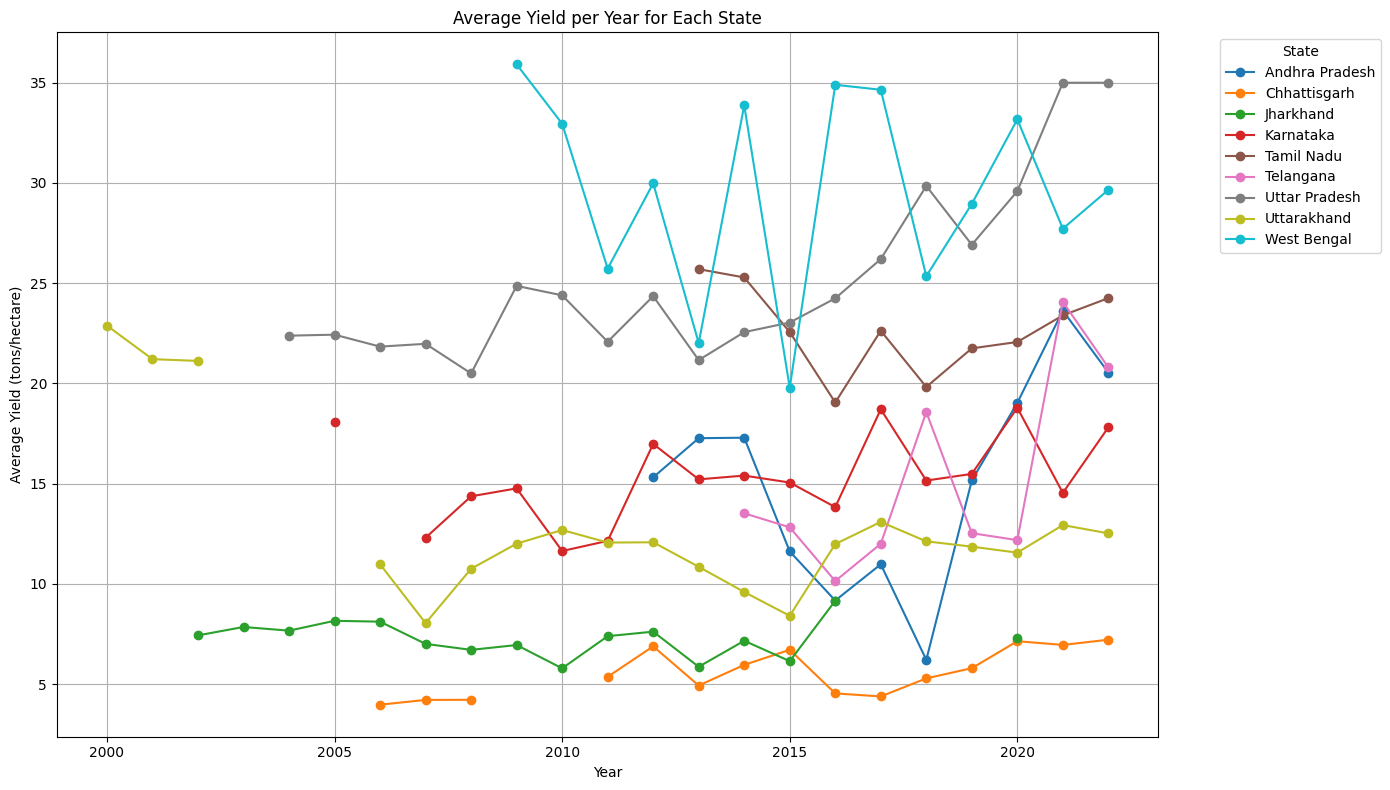

In [ ]:
df['year'] = df['temperature_recorded_date'].dt.year

# Group by 'state_name' and 'year', then compute average yield
state_year_yield = df.groupby(['state_name', 'year'])['yield'].mean().reset_index()

# Pivot table for plotting: index = year, columns = state_name, values = average yield
pivot_yield = state_year_yield.pivot(index='year', columns='state_name', values='yield')

# Plot
plt.figure(figsize=(14, 8))
pivot_yield.plot(marker='o', figsize=(14, 8), colormap='tab10')

plt.title("Average Yield per Year for Each State")
plt.xlabel("Year")
plt.ylabel("Average Yield (tons/hectare)")
plt.grid(True)
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

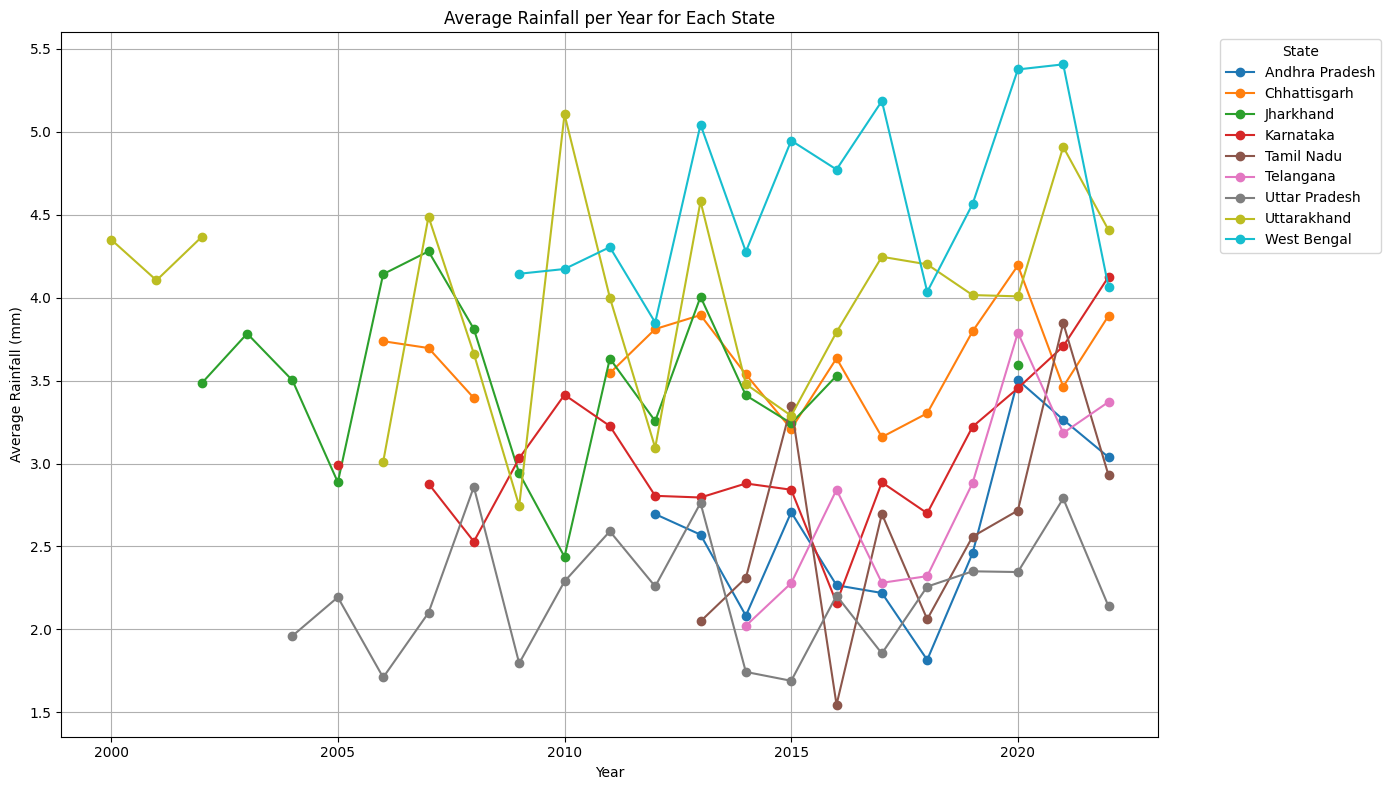

<Figure size 1400x800 with 0 Axes>

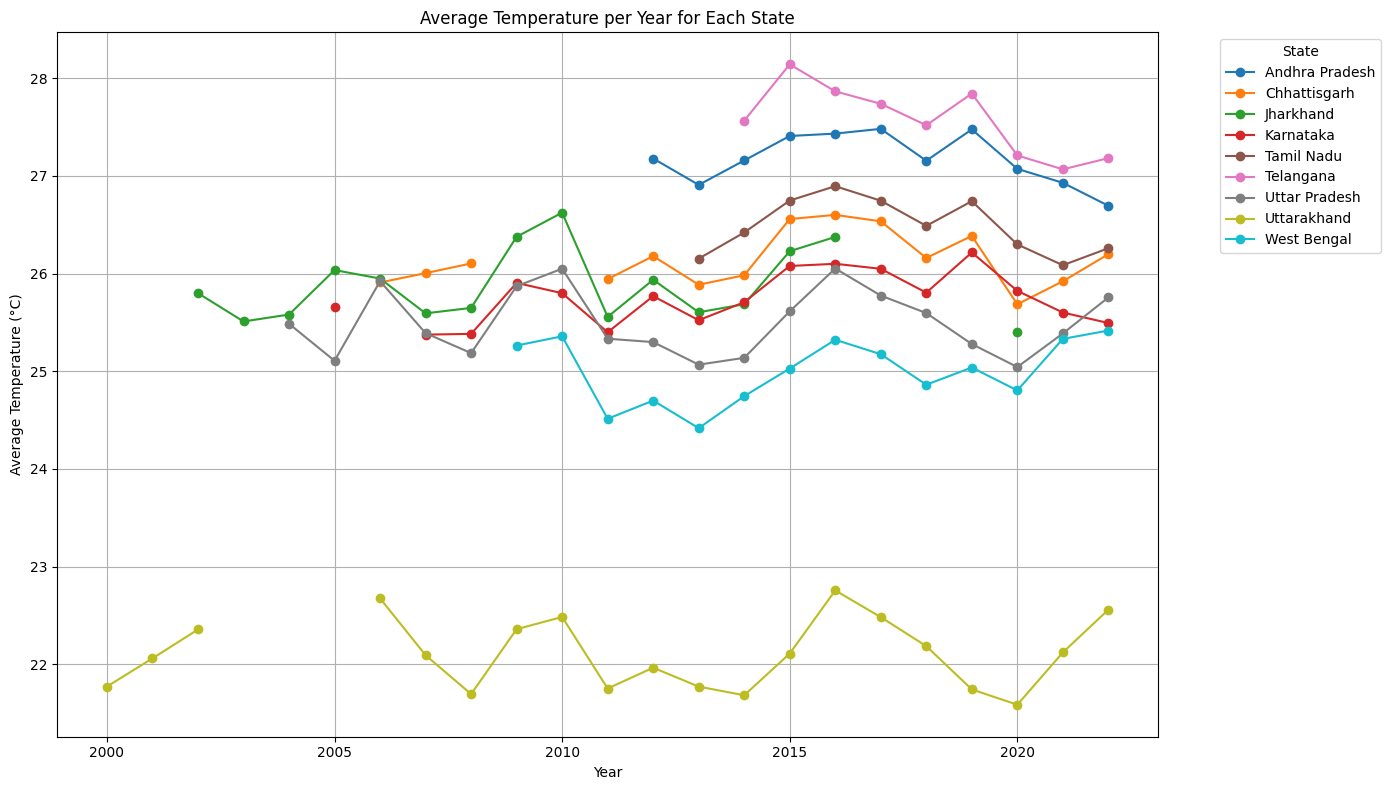

In [ ]:
df['avg_temp'] = (df['state_temperature_max_val'] + df['state_temperature_min_val']) / 2
state_year_stats = df.groupby(['state_name', 'year'])[['state_rainfall_val', 'avg_temp']].mean().reset_index()

# Pivot for rainfall
pivot_rainfall = state_year_stats.pivot(index='year', columns='state_name', values='state_rainfall_val')

# Pivot for temperature
pivot_temp = state_year_stats.pivot(index='year', columns='state_name', values='avg_temp')

# Plotting Rainfall
plt.figure(figsize=(14, 8))
pivot_rainfall.plot(marker='o', figsize=(14, 8), colormap='tab10')
plt.title("Average Rainfall per Year for Each State")
plt.xlabel("Year")
plt.ylabel("Average Rainfall (mm)")
plt.grid(True)
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plotting Temperature
plt.figure(figsize=(14, 8))
pivot_temp.plot(marker='o', figsize=(14, 8), colormap='tab10')
plt.title("Average Temperature per Year for Each State")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

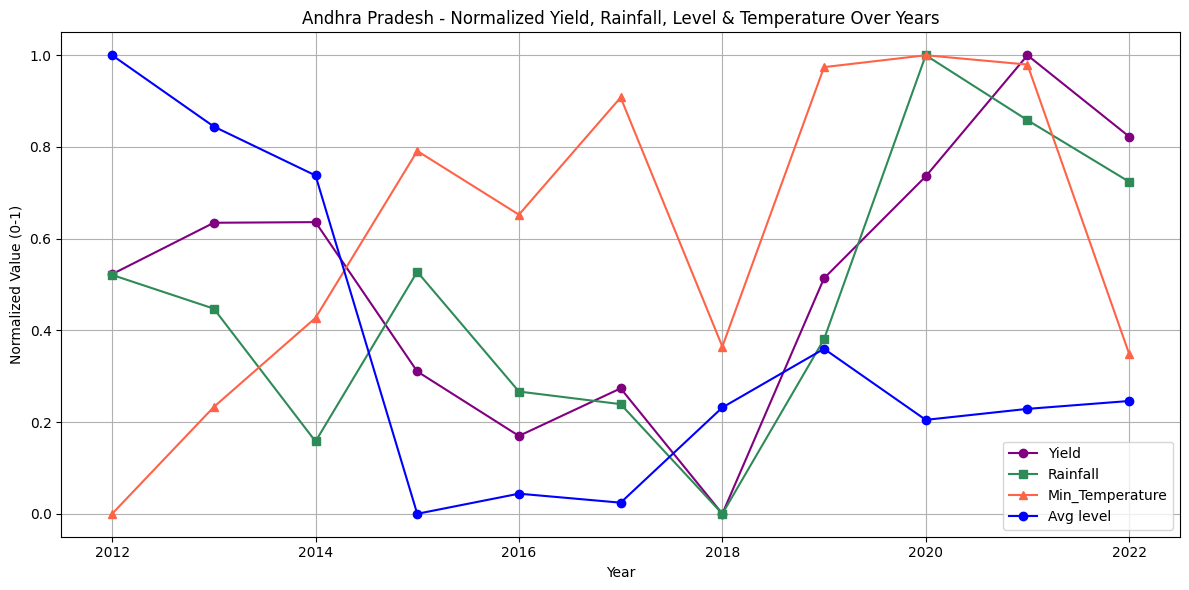

In [ ]:
# Filter Andhra Pradesh
ap_df = df[df['state_name'] == 'Andhra Pradesh']

# Group by year and take average
yearly = ap_df.groupby('year')[['yield', 'state_rainfall_val', 'state_temperature_min_val','Level']].mean().reset_index()

# Normalize each column to [0,1] using min-max scaling
yearly_norm = yearly.copy()
for col in ['yield', 'state_rainfall_val', 'state_temperature_min_val','Level']:
    yearly_norm[col] = (yearly[col] - yearly[col].min()) / (yearly[col].max() - yearly[col].min())

# Plot all three normalized metrics
plt.figure(figsize=(12, 6))
plt.plot(yearly_norm['year'], yearly_norm['yield'], label='Yield', marker='o', color='purple')
plt.plot(yearly_norm['year'], yearly_norm['state_rainfall_val'], label='Rainfall', marker='s', color='seagreen')
plt.plot(yearly_norm['year'], yearly_norm['state_temperature_min_val'], label='Min_Temperature', marker='^', color='tomato')
plt.plot(yearly_norm['year'], yearly_norm['Level'], label='Avg level', marker='o', color='blue')

plt.title("Andhra Pradesh - Normalized Yield, Rainfall, Level & Temperature Over Years")
plt.xlabel("Year")
plt.ylabel("Normalized Value (0-1)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

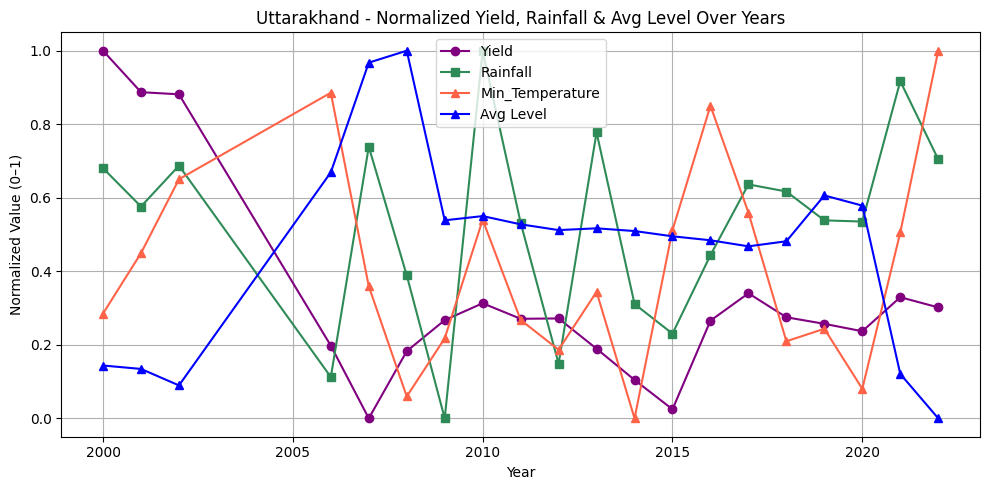

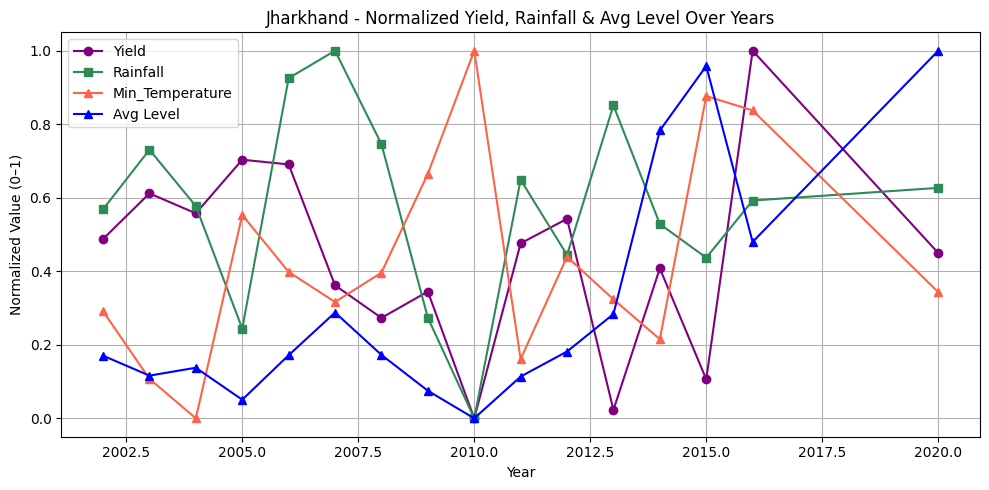

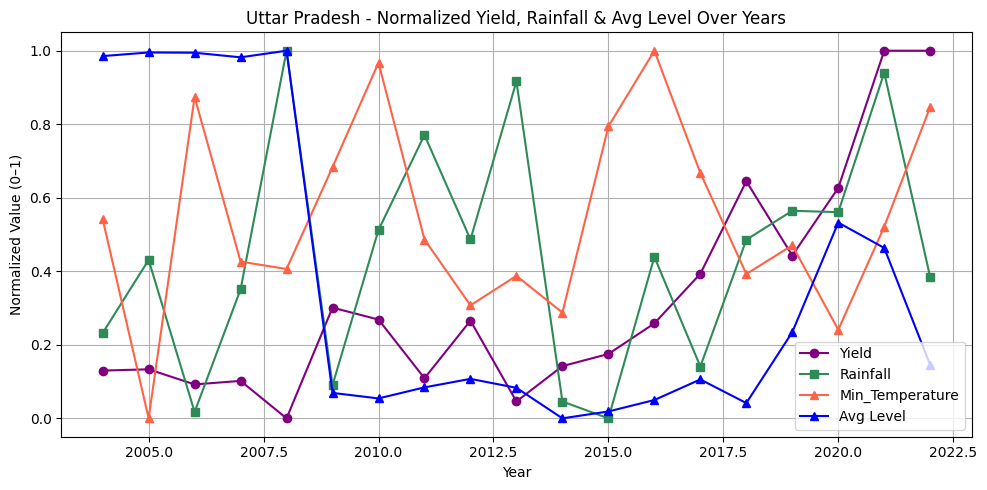

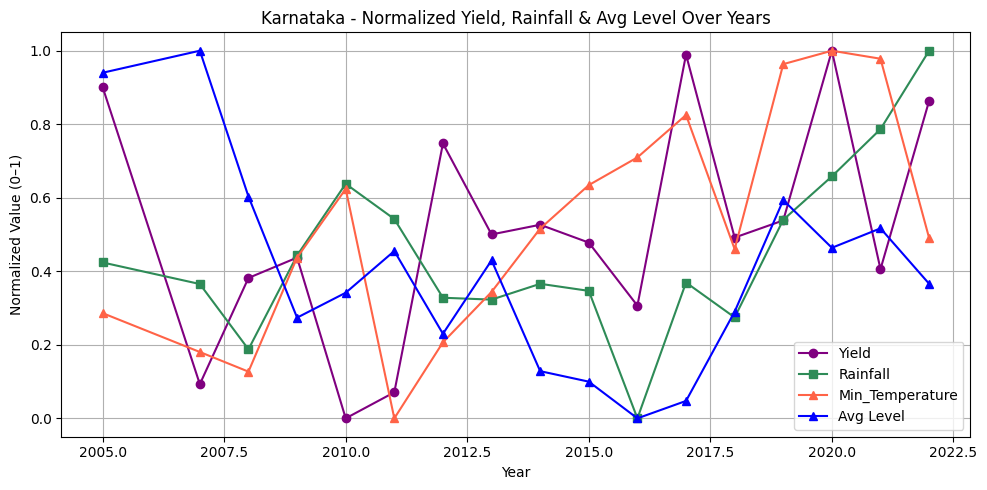

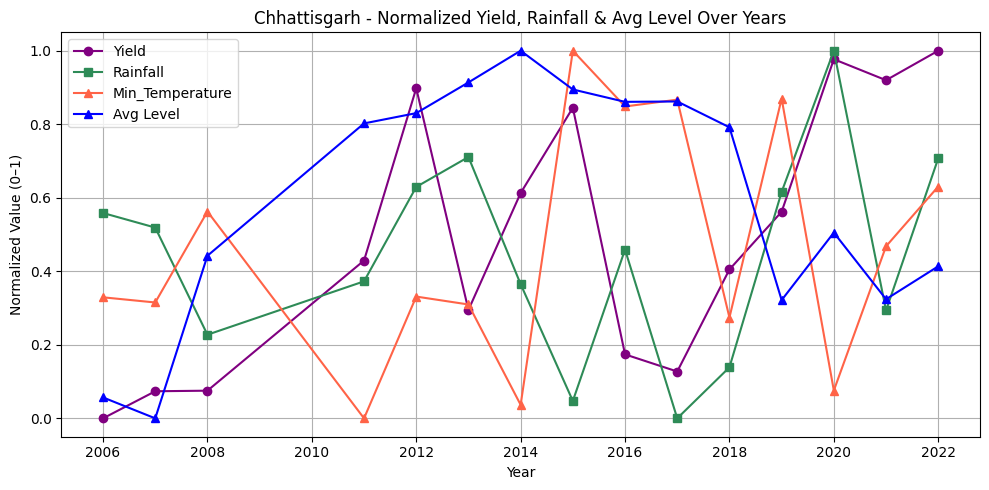

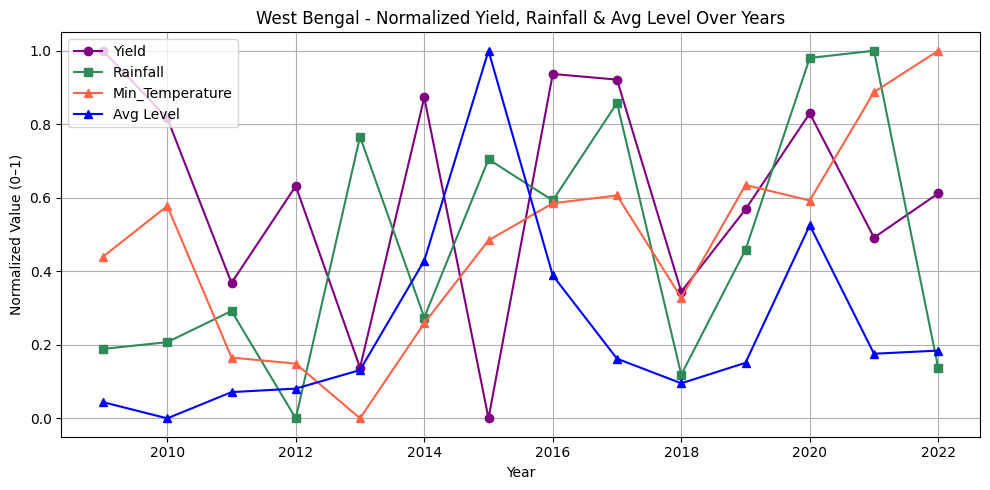

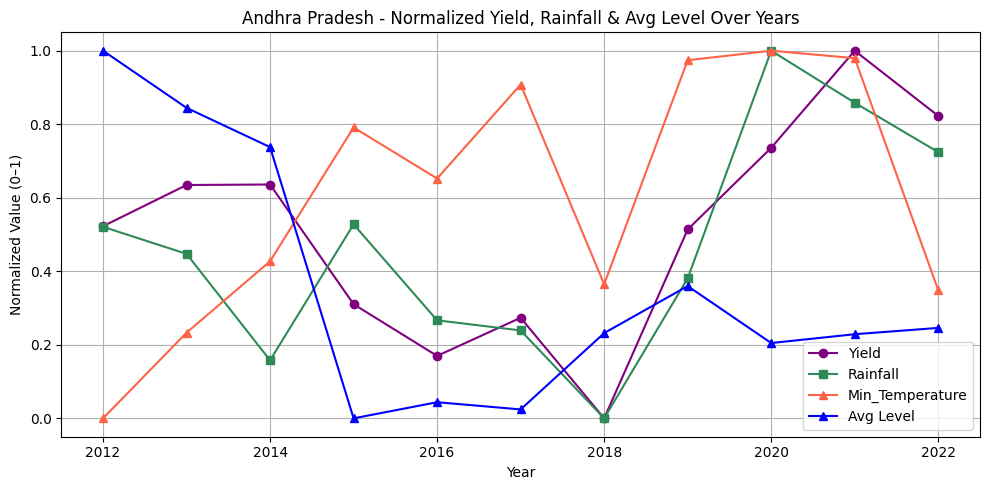

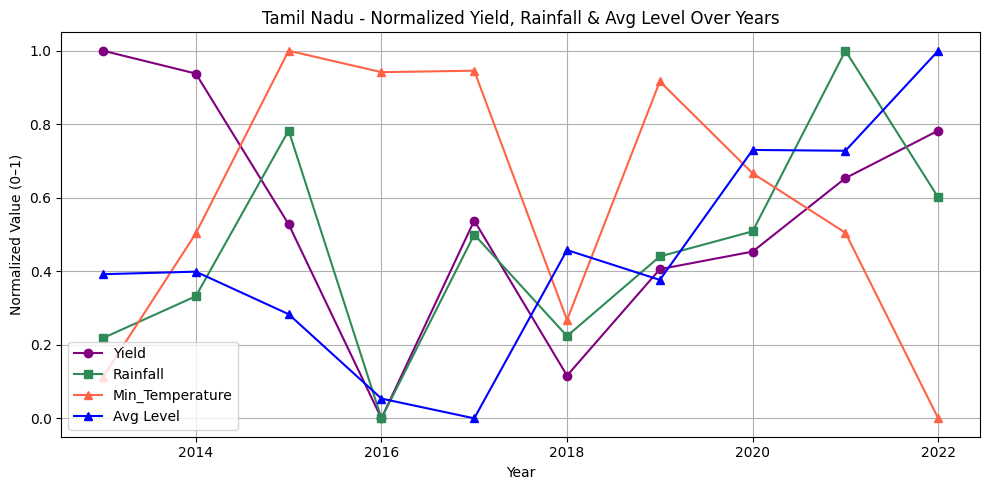

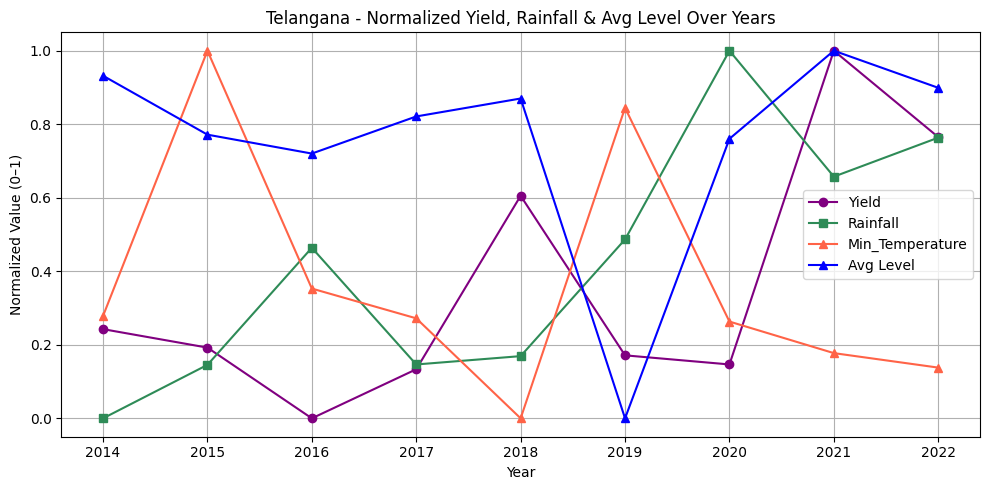

In [ ]:
states = df['state_name'].unique()

# Create a plot for each state
for state in states:
    state_df = df[df['state_name'] == state]

    # Group by year and calculate averages
    yearly = state_df.groupby('year')[['yield', 'state_rainfall_val','state_temperature_min_val', 'Level']].mean().reset_index()

    # Skip states with insufficient data
    if len(yearly) < 3:
        continue

    # Normalize the values
    yearly_norm = yearly.copy()
    for col in ['yield', 'state_rainfall_val','state_temperature_min_val', 'Level']:
        col_min = yearly[col].min()
        col_max = yearly[col].max()
        if col_max != col_min:
            yearly_norm[col] = (yearly[col] - col_min) / (col_max - col_min)
        else:
            yearly_norm[col] = 0.5  # if all values are the same

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(yearly_norm['year'], yearly_norm['yield'], label='Yield', marker='o', color='purple')
    plt.plot(yearly_norm['year'], yearly_norm['state_rainfall_val'], label='Rainfall', marker='s', color='seagreen')
    plt.plot(yearly_norm['year'], yearly_norm['state_temperature_min_val'], label='Min_Temperature', marker='^', color='tomato')
    plt.plot(yearly_norm['year'], yearly_norm['Level'], label='Avg Level', marker='^', color='blue')

    plt.title(f"{state} - Normalized Yield, Rainfall & Avg Level Over Years")
    plt.xlabel("Year")
    plt.ylabel("Normalized Value (0–1)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
# Aggregate by year and state
agg_df = df.groupby([ 'year'])[
    ['yield', 'avg_temp', 'state_rainfall_val', 'Level','FRL','Current Live Storage']].mean().dropna().reset_index()
# Define features and target
X = agg_df[['avg_temp', 'state_rainfall_val', 'Level','FRL','Current Live Storage']]
y = agg_df['yield']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)
# Predict on test set
y_pred = model.predict(X_test)

# Evaluate the model on test set
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

model_coef = model.coef_
model_intercept = model.intercept_

# Predict on training set
y_train_pred = model.predict(X_train)

# Evaluate on training data
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

print("Test Set Evaluation:")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print("\nTraining Set Evaluation:")
print(f"RMSE: {train_rmse:.4f}")
print(f"R² Score: {train_r2:.4f}")

Test Set Evaluation:
RMSE: 2.4435
R² Score: 0.6277

Training Set Evaluation:
RMSE: 1.6317
R² Score: 0.7726


In [ ]:
#model without aggregating data
# Aggregate by year and state
agg_df = df
# One-hot encode the 'state_name'
state_ohe = pd.get_dummies(agg_df['state_name'], prefix='state')
year_ohe = pd.get_dummies(agg_df['year'], prefix='year')

# Combine with features
X = pd.concat([agg_df[['state_temperature_min_val', 'state_rainfall_val', 'Level','FRL','Current Live Storage']], state_ohe,year_ohe], axis=1)
y = agg_df['yield']


# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate the model on test set
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

model_coef = model.coef_
model_intercept = model.intercept_

# Predict on training set
y_train_pred = model.predict(X_train)

# Evaluate on training data
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

print("Test Set Evaluation:")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print("\nTraining Set Evaluation:")
print(f"RMSE: {train_rmse:.4f}")
print(f"R² Score: {train_r2:.4f}")

Test Set Evaluation:
RMSE: 2.7027
R² Score: 0.8966

Training Set Evaluation:
RMSE: 2.6795
R² Score: 0.8984
